# Quantum Computing with Python: Basics

### 0 - Setup

In [1]:
#pip install qiskit==2.3.0

from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector

q = QuantumCircuit(1,0) #circuit with 1 quantum bit and 0 classic bit
state = Statevector.from_instruction(q) #measure state
state.probabilities() #print prob%

array([1., 0.])

In [2]:
print(f"[q=0 {round(state.probabilities()[0]*100)}%, q=1 {round(state.probabilities()[1]*100)}%]")

[q=0 100%, q=1 0%]


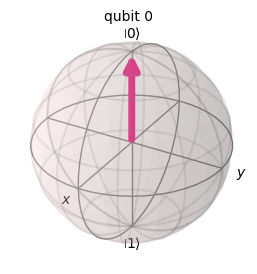

In [3]:
from qiskit.visualization import plot_bloch_multivector

plot_bloch_multivector(state, figsize=(3,3))

### 1 - Qubits

###### Superposition

[q=0 50%, q=1 50%]


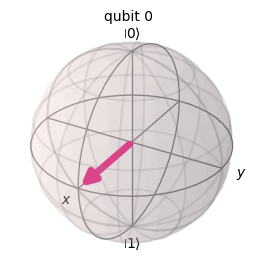

In [37]:
q = QuantumCircuit(1,0)
q.h(qubit=0) #add Superposition on the 1st qubit (we have only 1)
state = Statevector.from_instruction(q) 
print(f"[q=0 {round(state.probabilities()[0]*100)}%, q=1 {round(state.probabilities()[1]*100)}%]")
plot_bloch_multivector(state, figsize=(3,3))

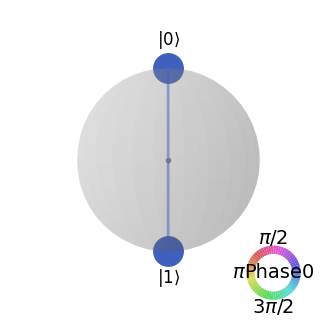

In [86]:
from qiskit.visualization import plot_state_qsphere

plot_state_qsphere(state, figsize=(4,4))

measured: 1


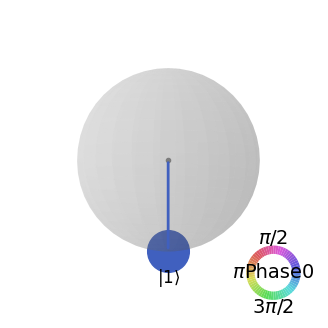

In [87]:
result, collapsed = state.measure() #Superposition disappears
print("measured:", result)
plot_state_qsphere(collapsed, figsize=(4,4)) #plot collapsed state

###### Entanglement

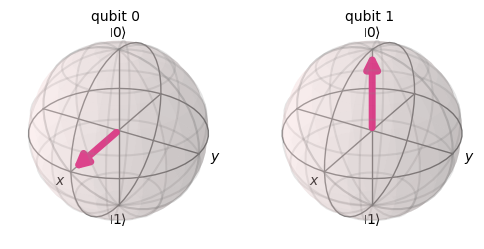

In [6]:
q = QuantumCircuit(2,0) #circuit with 2 quantum bits and 0 classic bit
q.h(qubit=[0]) #add Superposition on the 1st qubit
state = Statevector.from_circuit(q) 
plot_bloch_multivector(state, figsize=(3,3))

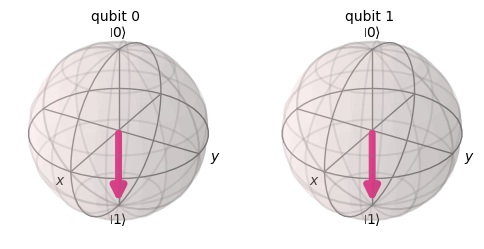

In [31]:
q.cx(control_qubit=0, target_qubit=1) #Entanglement
state = Statevector.from_circuit(q)
result, collapsed = state.measure([0]) #measure the 1st qubit
plot_bloch_multivector(collapsed, figsize=(3,3))

### 2 - Circuits

###### Gates

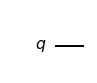

In [39]:
q = QuantumCircuit(1,0) #circuit with 1 quantum bit and 0 classic bit

q.draw(output="mpl", scale=0.7) #show circuit with matplotlib

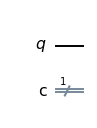

In [40]:
q = QuantumCircuit(1,1) #add 1 classic bit

q.draw(output="mpl", scale=0.7)

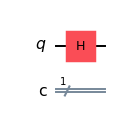

In [41]:
q = QuantumCircuit(1,1)
q.h(0) #Hadamard gate (Superposition)

q.draw(output="mpl", scale=0.7)

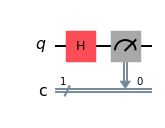

In [42]:
q = QuantumCircuit(1,1)
q.h(qubit=0)
q.measure(qubit=0, cbit=0) #measure qubit with classic bit

q.draw(output="mpl", scale=0.7)

###### Simulation

In [62]:
#pip install qiskit-aer==0.17.2

from qiskit_aer import AerSimulator

sim = AerSimulator()
result = sim.run(q, shots=1000).result()
result.get_counts()

{'1': 500, '0': 500}

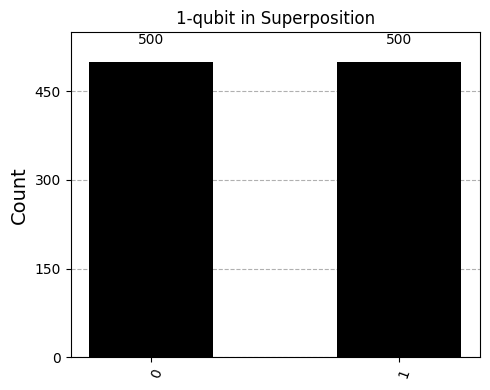

In [63]:
from qiskit.visualization import plot_histogram

plot_histogram(result.get_counts(), figsize=(5,4), color="black", title="1-qubit in Superposition")

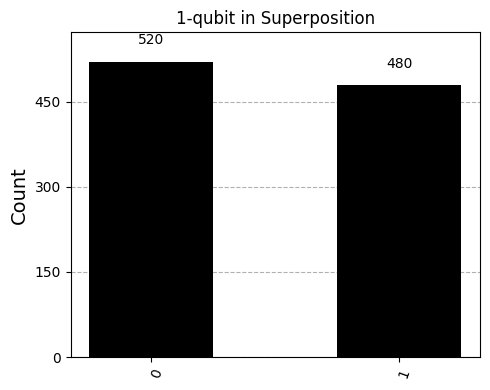

In [67]:
from qiskit_aer import noise

n = noise.NoiseModel()
error = noise.depolarizing_error(param=0.10, num_qubits=1) #10% error probability
n.add_all_qubit_quantum_error(error=error, instructions=['h'])

sim = AerSimulator(noise_model=n)
result = sim.run(q, shots=1000).result()
plot_histogram(result.get_counts(), figsize=(5,4), color="black", title="1-qubit in Superposition")

### 3 - Algorithms

###### Crack Password

In [4]:
password = "k"

password_bin = ''.join(format(ord(c), '08b') for c in password)
print(password, "=", password_bin)

k = 01101011


In [5]:
def password_check(guess, real):
    return guess == real

password_check(guess="ciao", real=password)

False

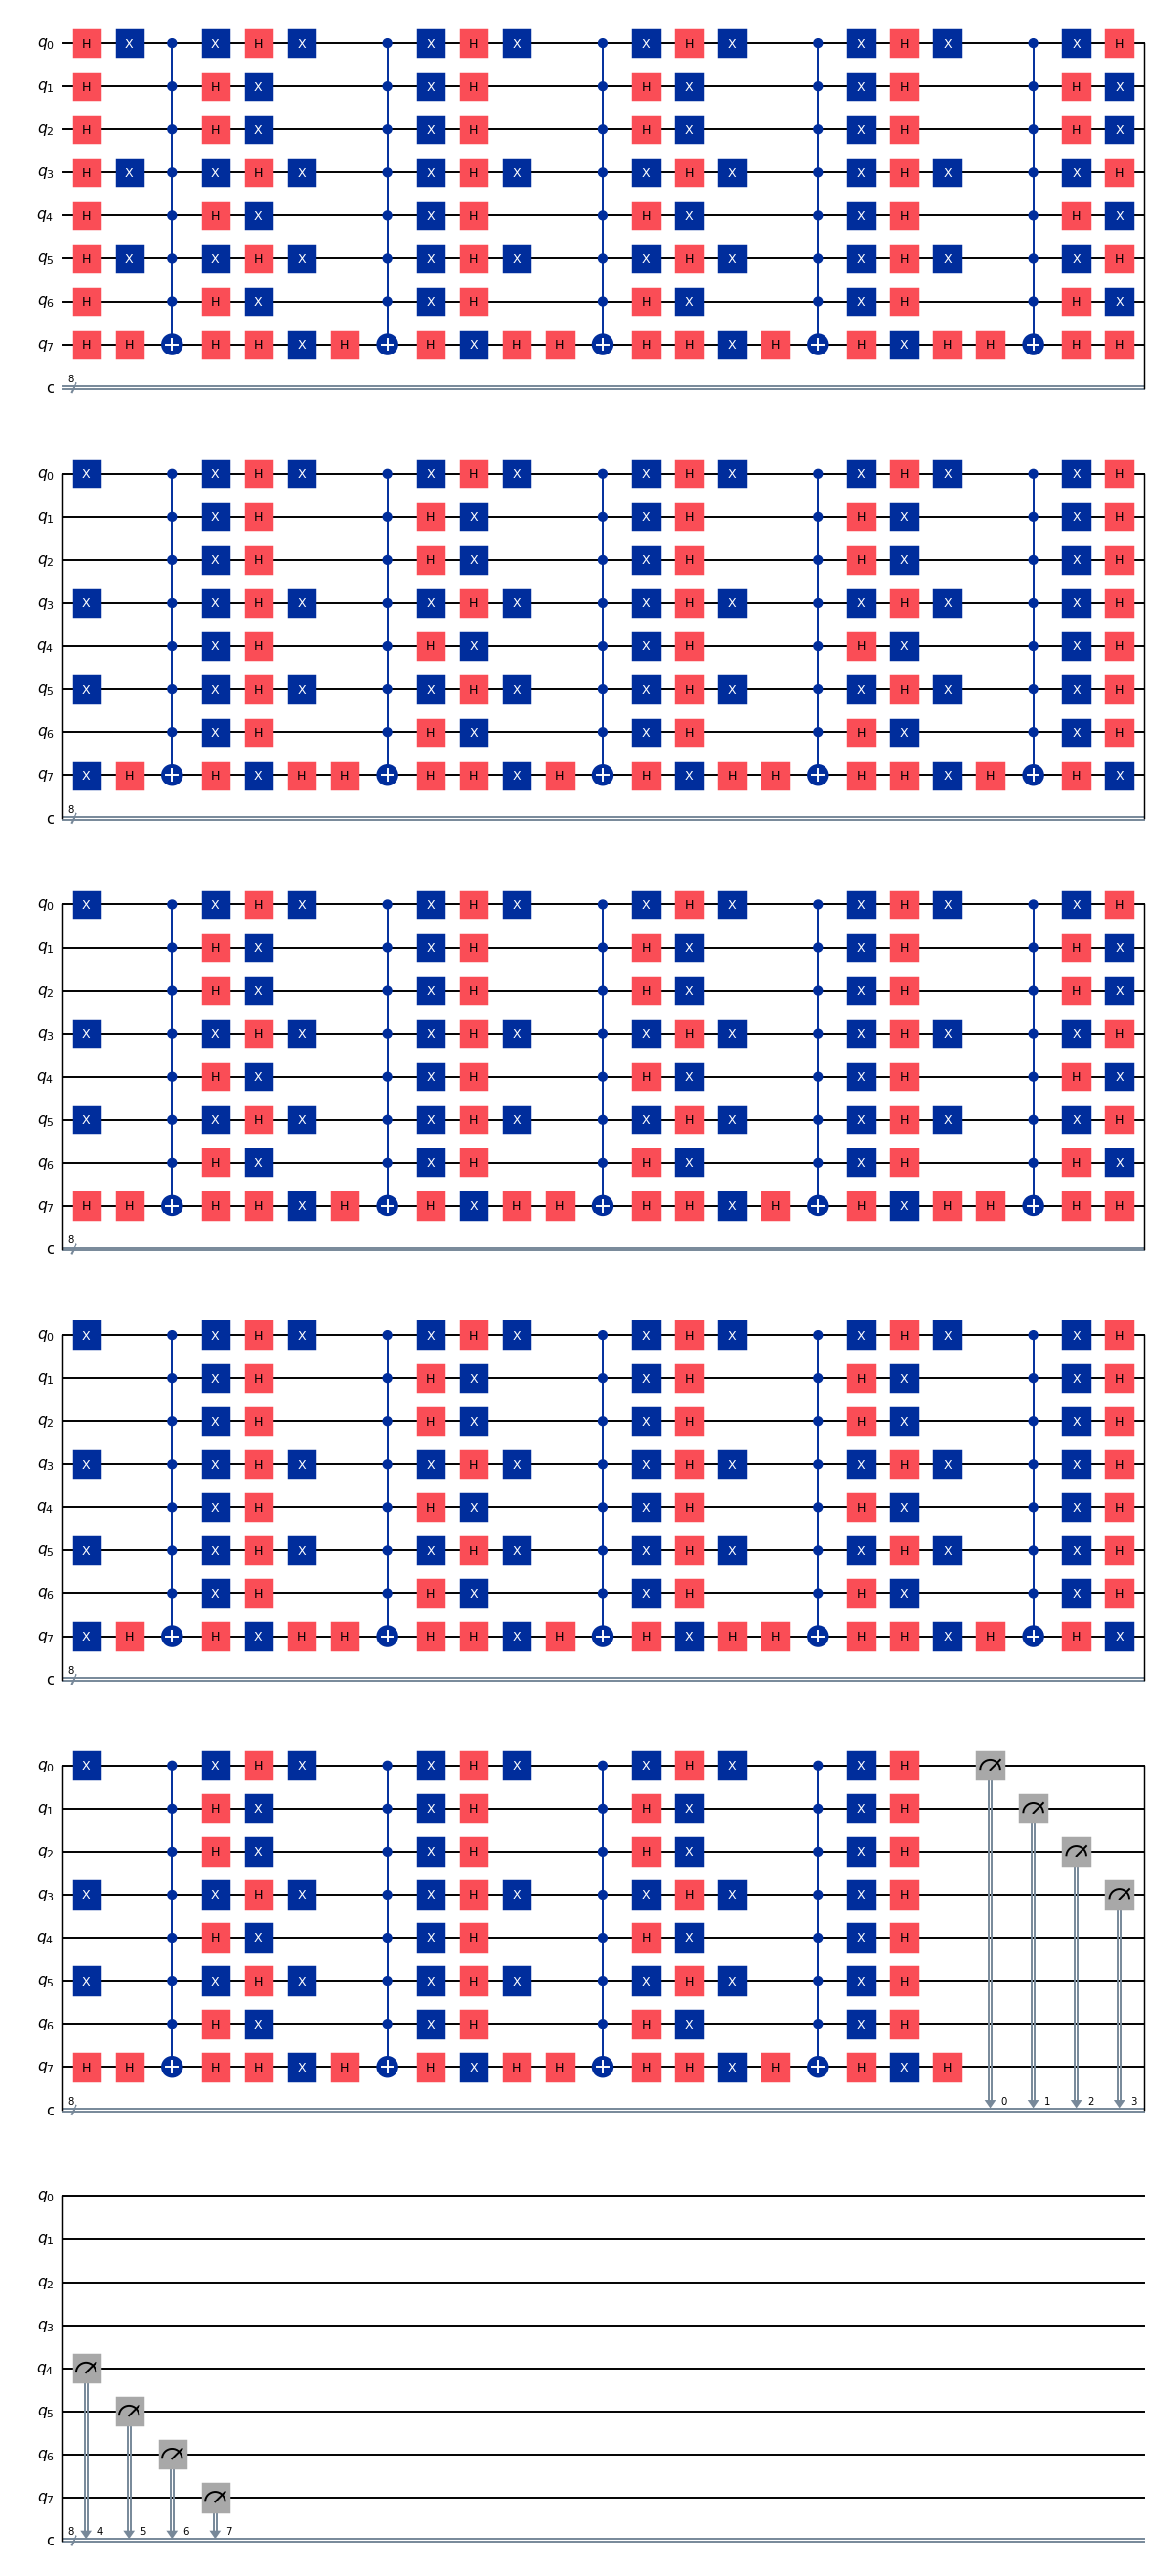

In [15]:
import numpy as np

n = len(password_bin) #this can go to infinite

## start circuit
q = QuantumCircuit(n,n)

## create superposition
for i in range(n):
    q.h(i)

## iterations
for _ in range(int(np.pi/4 * np.sqrt(2**n))):
    
    ### orcale
    for guess in range(2**n):
        guess_bin = format(guess, f"0{n}b")
        if password_check(guess=guess_bin, real=password_bin):
            for i,bit in enumerate(guess_bin):
                if bit == "0":
                    q.x(i)
            q.h(n-1)
            q.mcx(control_qubits=list(range(n-1)), target_qubit=n-1)
            q.h(n-1)
            for i,bit in enumerate(guess_bin):
                if bit == "0":
                    q.x(i)
    
    ### diffusion
    for i in range(n):
        q.h(i)
        q.x(i)
    q.h(n-1)
    q.mcx(control_qubits=list(range(n-1)), target_qubit=n-1)
    q.h(n-1)
    for i in range(n):
        q.x(i)
        q.h(i)

## measurement
q.measure(qubit=range(n), cbit=range(n))

## plot
q.draw(output="mpl", scale=0.7)

In [23]:
from qiskit_aer import AerSimulator

## run simulation
sim = AerSimulator()
res = sim.run(q, shots=1000).result()
res_bin = list(res.get_counts().keys())[0]
res_bin

'11010110'

In [24]:
## decode binary
bytes_list = [res_bin[i:i+8] for i in range(0, len(res_bin), 8)]
res = ''.join([chr(int(b,2)) for b in bytes_list])
print(res)  

Ö
